# MarioRL — Aprendizaje por Refuerzo con Q-learning



## ¿De qué trata este reporte?

En este notebook implementamos un agente de **Q-learning** que aprende a jugar un mini-juego estilo Mario Bros desde cero.

El agente empieza sin saber absolutamente nada: muere en los primeros pasos. Con el tiempo, a base de prueba y error, aprende a **saltar obstáculos** y **recolectar monedas** hasta lograr sobrevivir **300 pasos seguidos**.

Al final generamos un **video evolutivo** que muestra exactamente cómo mejoró el agente a lo largo del entrenamiento.



## Conceptos clave

| Concepto | Descripción |
|---|---|
| **Agente** | Mario — toma decisiones en cada paso |
| **Ambiente** | El mundo del juego — obstáculos y monedas |
| **Estado** | Lo que el agente observa: distancia al obstáculo, altura, velocidad, distancia a moneda |
| **Acción** | Quedarse quieto (0) o saltar (1) |
| **Recompensa** | +1 por sobrevivir, +5 por moneda, −10 por chocar |
| **Q-table** | Tabla donde el agente guarda qué tan buena es cada acción en cada situación |
| **ε-greedy** | Estrategia que balancea exploración (probar cosas nuevas) vs explotación (usar lo aprendido) |

## 1. Instalación y configuración

Antes de empezar necesitamos instalar algunas librerías:

- **pyvirtualdisplay**: crea una pantalla virtual en el servidor de Colab (que no tiene monitor físico) para poder renderizar gráficas.
- **imageio / imageio-ffmpeg**: permiten guardar secuencias de imágenes como video `.mp4`.
- **matplotlib**: genera las imágenes del juego cuadro por cuadro.
- **numpy**: manejo de arreglos y operaciones matemáticas.

También importamos todo al inicio para tener un entorno limpio y ordenado.

In [10]:
# Instalar librerías necesarias (la salida se suprime para mantener el notebook limpio)
!pip install pyvirtualdisplay imageio imageio-ffmpeg matplotlib numpy > /dev/null 2>&1

# ── Importaciones ─────────────────────────────────────────────────────────────
import numpy as np                        # operaciones numéricas y arreglos
import matplotlib.pyplot as plt           # generación de imágenes del juego
import matplotlib.patches as patches      # formas geométricas (rectángulos, círculos)
import matplotlib.patheffects as pe       # efectos visuales (bordes en texto)
import imageio                            # guardar frames como video
import base64                             # codificar video para mostrarlo en Colab
import time                               # medir tiempo de entrenamiento
from pathlib import Path                  # manejo de archivos
from IPython.display import HTML, display # mostrar video inline en el notebook
from pyvirtualdisplay import Display      # pantalla virtual para renderizado

# Iniciar la pantalla virtual (necesario en Colab para usar matplotlib sin monitor)
vdisplay = Display(visible=0, size=(700, 350))
vdisplay.start()

print('✅ Librerías instaladas e importadas correctamente')
print('✅ Display virtual iniciado')

✅ Librerías instaladas e importadas correctamente
✅ Display virtual iniciado


## 2. Ambiente personalizado — MarioEnv

En lugar de usar un ambiente de Gymnasium, creamos nuestro propio ambiente desde cero.
Esto nos da control total sobre las reglas del juego y nos permite entender mejor cómo funciona el ciclo de aprendizaje.

### ¿Cómo funciona el mundo?

El mundo es una **pista horizontal** de 20 casillas de ancho. Mario siempre está en la columna 2 y el mundo se mueve hacia él:

```
[ cielo                                    ]
[ nubes                 🪙        🪙        ]
[          🟩    🟩               🟩        ]
[🏃 suelo suelo suelo suelo suelo suelo    ]
```

### Estado del agente

En cada paso, el agente observa 4 valores discretizados:

| Variable | Rango | Significado |
|---|---|---|
| `dist_obst` | 0–8 | Distancia al obstáculo más cercano |
| `alt_mario` | 0–2 | Altura actual de Mario |
| `vel_vert` | 0–4 | Velocidad vertical (0=cayendo, 2=quieto, 4=subiendo) |
| `dist_mon` | 0–8 | Distancia a la moneda más cercana |

### Sistema de recompensas

| Evento | Recompensa |
|---|---|
| Sobrevivir un paso | +1 |
| Recoger una moneda | +5 |
| Chocar con obstáculo | −10 |

### Condición de victoria
Sobrevivir **300 pasos seguidos** sin chocar con ningún obstáculo.

In [11]:
# ── Constantes del juego ──────────────────────────────────────────────────────
ANCHO          = 20    # ancho del mundo en casillas
MAX_SALTO      = 2     # altura máxima que puede alcanzar Mario al saltar
RECOMP_MON     = 5     # recompensa por recoger una moneda
RECOMP_OBS     = -10   # penalización por chocar con un obstáculo
RECOMP_PAS     = 1     # recompensa por sobrevivir un paso
PASOS_VICTORIA = 300   # pasos necesarios para considerar que el agente ganó
QUIETO, SALTAR = 0, 1  # identificadores de las acciones posibles
N_ACCIONES     = 2     # total de acciones disponibles

class MarioEnv:
    """
    Ambiente de juego estilo Mario Bros.

    El agente (Mario) avanza automáticamente. En cada paso decide
    si saltar o quedarse quieto para esquivar obstáculos y recoger monedas.
    """

    def __init__(self):
        self.reset()

    def reset(self):
        """Reinicia el ambiente al estado inicial para comenzar un nuevo episodio."""
        self.mario_y          = 0     # altura inicial de Mario (suelo)
        self.vel_y            = 0     # velocidad vertical inicial
        self.saltando         = False # Mario no está saltando al inicio
        self.paso             = 0     # contador de pasos del episodio
        self.terminado        = False # el episodio no ha terminado
        self.recompensa_total = 0     # acumulador de recompensa
        self.pos_mario        = 2     # Mario siempre en columna 2
        self._generar_mundo()
        return self._estado()

    def _generar_mundo(self):
        """Genera obstáculos y monedas con posiciones aleatorias bien espaciadas."""
        # Obstáculos separados al menos 6 casillas entre sí
        # y empezando a partir de la casilla 8 para dar tiempo de reacción
        posicoes = []
        candidato = np.random.randint(8, 12)
        for _ in range(3):
            posicoes.append(candidato)
            candidato += np.random.randint(6, 10)
        self.obstaculos = posicoes

        # Monedas en posiciones libres (no donde hay obstáculos)
        libres = [x for x in range(4, candidato + 5) if x not in self.obstaculos]
        self.monedas = sorted(
            np.random.choice(libres, size=3, replace=False).tolist()
        )

    def _estado(self):
        """Calcula y devuelve el estado actual del agente como tupla discreta."""
        # Distancia al obstáculo más cercano que está adelante de Mario
        obs_ahead = [o - self.pos_mario for o in self.obstaculos if o > self.pos_mario]
        mon_ahead = [m - self.pos_mario for m in self.monedas    if m > self.pos_mario]

        # Limitar a máximo 8 para mantener la tabla pequeña
        dist_obst = min(min(obs_ahead) if obs_ahead else ANCHO - 1, 8)
        dist_mon  = min(min(mon_ahead) if mon_ahead else ANCHO - 1, 8)

        # Retornar tupla: (dist_obst, alt_mario, vel_vert+2, dist_mon)
        # vel_vert+2 para convertir [-2,2] → [0,4] (índices positivos)
        return (dist_obst, self.mario_y, self.vel_y + 2, dist_mon)

    def step(self, accion):
        """Ejecuta una acción y devuelve (nuevo_estado, recompensa, terminado)."""
        recompensa = RECOMP_PAS  # recompensa base por sobrevivir el paso

        # ── Física del salto ──────────────────────────────────────────────────
        # Solo se puede saltar si Mario está en el suelo y no está ya saltando
        if accion == SALTAR and self.mario_y == 0 and not self.saltando:
            self.vel_y    = 2     # impulso hacia arriba
            self.saltando = True

        # Aplicar velocidad vertical
        self.mario_y += self.vel_y

        # Límite superior del salto: empieza a caer
        if self.mario_y > MAX_SALTO:
            self.mario_y = MAX_SALTO
            self.vel_y   = -1

        # Límite inferior: llegó al suelo
        if self.mario_y <= 0:
            self.mario_y  = 0
            self.vel_y    = 0
            self.saltando = False

        # ── Mover el mundo (obstáculos y monedas se acercan) ──────────────────
        self.obstaculos = [o - 1 for o in self.obstaculos]
        self.monedas    = [m - 1 for m in self.monedas]

        # Eliminar obstáculos que ya pasaron y generar nuevos al final
        self.obstaculos = [o for o in self.obstaculos if o > 0]
        while len(self.obstaculos) < 3:
            self.obstaculos.append(ANCHO + np.random.randint(4, 10))
        self.obstaculos = sorted(self.obstaculos)

        # ── Detectar colisión con obstáculo ───────────────────────────────────
        # Colisión ocurre si Mario está en el suelo y hay un obstáculo en su posición
        for o in self.obstaculos:
            if abs(o - self.pos_mario) < 1 and self.mario_y == 0:
                recompensa    += RECOMP_OBS  # penalización por choque
                self.terminado = True
                break

        # ── Detectar recolección de monedas ───────────────────────────────────
        # Las monedas están a altura 2, Mario las recoge si salta a esa altura
        nuevas = []
        for m in self.monedas:
            if m > 0:
                if abs(m - self.pos_mario) < 1 and self.mario_y == 2:
                    recompensa += RECOMP_MON  # recompensa por moneda
                else:
                    nuevas.append(m)
        self.monedas = nuevas
        while len(self.monedas) < 3:
            self.monedas.append(ANCHO + np.random.randint(3, 12))
        self.monedas = sorted(self.monedas)

        # ── Actualizar contadores ─────────────────────────────────────────────
        self.paso             += 1
        self.recompensa_total += recompensa

        # Condición de victoria: sobrevivir PASOS_VICTORIA pasos
        if self.paso >= PASOS_VICTORIA:
            self.terminado = True

        return self._estado(), recompensa, self.terminado

# ── Prueba rápida del ambiente ────────────────────────────────────────────────
env_test = MarioEnv()
obs = env_test.reset()
print('Estado inicial:', obs)
print('Significado:    (dist_obst, alt_mario, vel_vert, dist_moneda)')
print(f'Obstáculos iniciales: {env_test.obstaculos}')
print(f'Monedas iniciales:    {env_test.monedas}')

Estado inicial: (8, 0, 2, 8)
Significado:    (dist_obst, alt_mario, vel_vert, dist_moneda)
Obstáculos iniciales: [10, 17, 25]
Monedas iniciales:    [12, 32, 33]


El ambiente se inicializó correctamente. Podemos ver que el primer obstáculo está **bien alejado** de Mario (columna 2), dándole tiempo suficiente para aprender a reaccionar.

## 3. Función de renderizado

Para visualizar lo que hace el agente necesitamos **dibujar el mundo** en cada paso.
Usamos `matplotlib` para construir la escena cuadro por cuadro:
cielo, suelo, nubes, tubos, monedas y Mario.

La función también acepta parámetros opcionales para mostrar:
- **HUD** (marcador) con episodio, paso, recompensa y epsilon
- **Etiquetas grandes** con el nombre de la fase
- **Pantallas especiales** de GAME OVER y Victoria

Cada imagen generada se guarda como un arreglo NumPy (RGB) que después se une en un video.

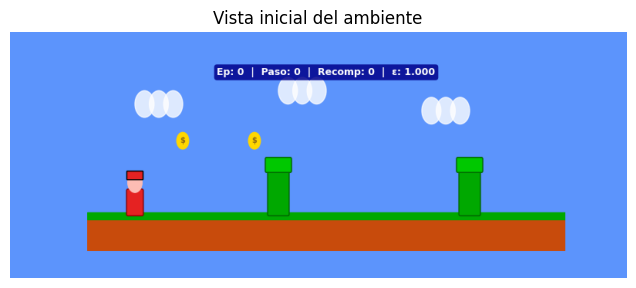

In [12]:
def render_mario(env, episodio=None, paso=None, recompensa=None,
                 epsilon=None, etiqueta=None, color_etiqueta='white',
                 subtitulo=None, game_over=False, victoria=False):
    """
    Dibuja el estado actual del juego y devuelve la imagen como arreglo RGB.

    Parámetros:
      env            : instancia del ambiente MarioEnv
      episodio       : número de episodio actual (para el HUD)
      paso           : paso actual dentro del episodio (para el HUD)
      recompensa     : recompensa acumulada (para el HUD)
      epsilon        : valor actual de epsilon (para el HUD)
      etiqueta       : texto grande centrado (título de fase)
      color_etiqueta : color del texto grande
      subtitulo      : texto explicativo debajo de la etiqueta
      game_over      : si True, muestra pantalla oscura de GAME OVER
      victoria       : si True, muestra pantalla dorada de victoria
    """
    fig, ax = plt.subplots(figsize=(8, 3.2))
    fig.patch.set_facecolor('#5c94fc')   # fondo azul cielo
    ax.set_facecolor('#5c94fc')
    ax.set_xlim(0, ANCHO)
    ax.set_ylim(-0.5, 5.2)
    ax.axis('off')                       # ocultar ejes

    # ── Suelo ─────────────────────────────────────────────────────────────────
    ax.add_patch(patches.Rectangle((0, -0.5), ANCHO, 1.0,
                                    color='#c84b0c', zorder=1))  # tierra café
    ax.add_patch(patches.Rectangle((0, 0.45), ANCHO, 0.2,
                                    color='#00a800', zorder=2))  # pasto verde

    # ── Nubes decorativas ─────────────────────────────────────────────────────
    for nx, ny in [(3, 3.9), (9, 4.3), (15, 3.7)]:
        for dx in [-0.6, 0, 0.6]:       # cada nube es 3 círculos superpuestos
            ax.add_patch(plt.Circle((nx + dx, ny), 0.4,
                                     color='white', alpha=0.8, zorder=1))

    # ── Obstáculos (tubos estilo Mario) ───────────────────────────────────────
    for ox in env.obstaculos:
        if -1 <= ox <= ANCHO + 1:        # solo dibujar los que están en pantalla
            # Cuerpo del tubo
            ax.add_patch(patches.FancyBboxPatch(
                (ox - 0.4, 0.6), 0.8, 1.3,
                boxstyle='round,pad=0.05',
                linewidth=1, edgecolor='#006400', facecolor='#00a800', zorder=3))
            # Cabeza del tubo (más ancha)
            ax.add_patch(patches.FancyBboxPatch(
                (ox - 0.5, 1.9), 1.0, 0.35,
                boxstyle='round,pad=0.05',
                linewidth=1, edgecolor='#006400', facecolor='#00c800', zorder=4))

    # ── Monedas ───────────────────────────────────────────────────────────────
    for mx in env.monedas:
        if -1 <= mx <= ANCHO + 1:
            ax.add_patch(plt.Circle((mx, 2.8), 0.25,
                                     color='#ffd700', zorder=3))  # moneda dorada
            ax.text(mx, 2.8, '$', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='#8B6914', zorder=4)

    # ── Mario ─────────────────────────────────────────────────────────────────
    mx_pos = env.pos_mario
    my_pos = env.mario_y + 0.6           # ajuste vertical sobre el suelo

    # Cuerpo rojo
    ax.add_patch(patches.FancyBboxPatch(
        (mx_pos - 0.3, my_pos), 0.6, 0.7,
        boxstyle='round,pad=0.05',
        linewidth=1, edgecolor='#8B0000', facecolor='#e52222', zorder=5))
    # Cabeza (color piel)
    ax.add_patch(plt.Circle((mx_pos, my_pos + 0.95), 0.3,
                              color='#FDBCB4', zorder=5))
    # Gorra roja
    ax.add_patch(patches.FancyBboxPatch(
        (mx_pos - 0.32, my_pos + 1.05), 0.64, 0.22,
        boxstyle='round,pad=0.02',
        facecolor='#e52222', zorder=6))

    # Indicador de salto (flecha amarilla)
    if env.saltando:
        ax.text(mx_pos, my_pos + 1.6, '↑', ha='center', va='center',
                fontsize=14, color='yellow', fontweight='bold', zorder=7)

    # ── HUD: información del entrenamiento ───────────────────────────────────
    hud = []
    if episodio   is not None: hud.append(f'Ep: {episodio}')
    if paso       is not None: hud.append(f'Paso: {paso}')
    if recompensa is not None: hud.append(f'Recomp: {recompensa:.0f}')
    if epsilon    is not None: hud.append(f'ε: {epsilon:.3f}')
    if hud:
        ax.text(ANCHO / 2, 4.85, '  |  '.join(hud),
                ha='center', va='center', fontsize=9,
                color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#00008B',
                          alpha=0.85, edgecolor='none'),
                zorder=10)

    # ── Etiqueta central de fase ──────────────────────────────────────────────
    if etiqueta:
        ax.text(ANCHO / 2, 3.2, etiqueta,
                ha='center', va='center', fontsize=18,
                color=color_etiqueta, fontweight='bold',
                path_effects=[pe.withStroke(linewidth=3, foreground='black')],
                zorder=11)
    if subtitulo and not game_over and not victoria:
        ax.text(ANCHO / 2, 2.5, subtitulo,
                ha='center', va='center', fontsize=10,
                color='white', style='italic',
                path_effects=[pe.withStroke(linewidth=2, foreground='black')],
                zorder=11)

    # ── Pantalla de GAME OVER ─────────────────────────────────────────────────
    if game_over:
        ax.add_patch(patches.Rectangle((0, -0.5), ANCHO, 6,
                                        color='black', alpha=0.55, zorder=12))
        ax.text(ANCHO / 2, 2.8, 'GAME OVER',
                ha='center', va='center', fontsize=22,
                color='#e52222', fontweight='bold',
                path_effects=[pe.withStroke(linewidth=4, foreground='black')],
                zorder=13)
        if subtitulo:
            ax.text(ANCHO / 2, 1.8, subtitulo,
                    ha='center', va='center', fontsize=10, color='white',
                    path_effects=[pe.withStroke(linewidth=2, foreground='black')],
                    zorder=13)

    # ── Pantalla de VICTORIA ──────────────────────────────────────────────────
    if victoria:
        ax.add_patch(patches.Rectangle((0, -0.5), ANCHO, 6,
                                        color='#000033', alpha=0.55, zorder=12))
        ax.text(ANCHO / 2, 3.0, '🏆  ¡GANÓ!',
                ha='center', va='center', fontsize=22,
                color='#ffd700', fontweight='bold',
                path_effects=[pe.withStroke(linewidth=4, foreground='black')],
                zorder=13)
        if subtitulo:
            ax.text(ANCHO / 2, 1.9, subtitulo,
                    ha='center', va='center', fontsize=10, color='white',
                    path_effects=[pe.withStroke(linewidth=2, foreground='black')],
                    zorder=13)

    # ── Capturar imagen como arreglo NumPy ────────────────────────────────────
    fig.canvas.draw()
    buf = fig.canvas.buffer_rgba()       # buffer RGBA del canvas
    img = np.asarray(buf)[:, :, :3]     # convertir a RGB (descartar canal alpha)
    plt.close(fig)                       # cerrar figura para liberar memoria
    return img

def mostrar_video(path):
    """Codifica un archivo .mp4 en base64 y lo muestra inline en el notebook."""
    video_bytes = Path(path).read_bytes()
    encoded     = base64.b64encode(video_bytes).decode()
    display(HTML(
        f'<video width="700" controls autoplay loop>'
        f'<source src="data:video/mp4;base64,{encoded}" type="video/mp4">'
        f'</video>'
    ))

def frames_etiqueta(env, texto, subtexto, color, n=18, **kwargs):
    """Genera N frames idénticos con una etiqueta de fase para usar como transición."""
    f = render_mario(env, etiqueta=texto, color_etiqueta=color,
                     subtitulo=subtexto, **kwargs)
    return [f] * n

# ── Mostrar un frame de prueba ────────────────────────────────────────────────
env_test = MarioEnv()
env_test.reset()
frame_prueba = render_mario(env_test, episodio=0, paso=0, recompensa=0, epsilon=1.0)
plt.figure(figsize=(8, 3.2))
plt.imshow(frame_prueba)
plt.axis('off')
plt.title('Vista inicial del ambiente')
plt.show()

La función de renderizado está lista. Podemos ver el mundo con Mario (rojo), los tubos verdes y las monedas doradas.

## 4. Agente aleatorio — Línea base

Antes de entrenar el agente con Q-learning, es importante establecer una **línea base**: ¿qué tan bien se desempeña un agente que actúa completamente al azar?

Esto nos permite comparar después cuánto mejoró el agente con el aprendizaje.

Un agente aleatorio:
- No tiene memoria ni aprendizaje
- En cada paso lanza un dado: 50% de probabilidad de saltar, 50% de quedarse quieto
- Sirve como referencia de rendimiento mínimo

Correremos **500 episodios** y graficaremos el histograma de recompensas.

Corriendo 500 episodios del agente aleatorio...
Recompensa promedio: 13.78
Recompensa máxima:   114
Recompensa mínima:   -4


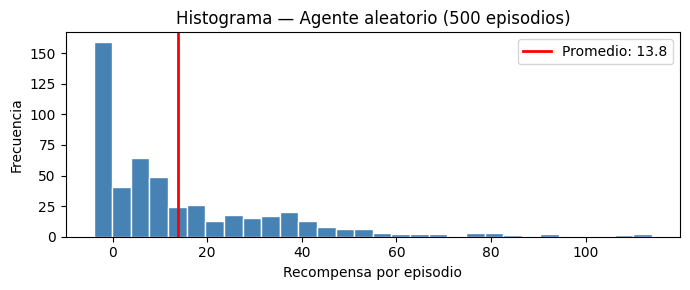

In [13]:
env              = MarioEnv()
recomp_aleatorio = []   # lista para guardar la recompensa de cada episodio

print('Corriendo 500 episodios del agente aleatorio...')

for ep in range(500):
    env.reset()
    recomp_ep = 0
    done      = False

    while not done:
        accion = np.random.randint(N_ACCIONES)   # acción completamente aleatoria
        _, recomp, done = env.step(accion)
        recomp_ep += recomp

    recomp_aleatorio.append(recomp_ep)

# ── Estadísticas del agente aleatorio ────────────────────────────────────────
print(f'Recompensa promedio: {np.mean(recomp_aleatorio):.2f}')
print(f'Recompensa máxima:   {np.max(recomp_aleatorio):.0f}')
print(f'Recompensa mínima:   {np.min(recomp_aleatorio):.0f}')

# ── Histograma de recompensas ─────────────────────────────────────────────────
plt.figure(figsize=(7, 3))
plt.hist(recomp_aleatorio, bins=30, color='steelblue', edgecolor='white')
plt.axvline(np.mean(recomp_aleatorio), color='red', linewidth=2,
            label=f'Promedio: {np.mean(recomp_aleatorio):.1f}')
plt.xlabel('Recompensa por episodio')
plt.ylabel('Frecuencia')
plt.title('Histograma — Agente aleatorio (500 episodios)')
plt.legend()
plt.tight_layout()
plt.show()

Como era de esperarse, el agente aleatorio tiene un rendimiento muy bajo y muy variable. La mayoría de los episodios terminan rápido porque el agente no sabe cuándo saltar.

Este valor promedio será nuestra **referencia**: el agente entrenado deberá superar ampliamente este número.

## 5. Preparación del Q-learning

### ¿Qué es Q-learning?

Q-learning es un algoritmo de aprendizaje por refuerzo que aprende **qué tan buena es cada acción en cada situación**. Esta información se guarda en una tabla llamada **Q-table**.

La fórmula de actualización es:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Donde:
- $s$ = estado actual, $a$ = acción tomada
- $r$ = recompensa recibida
- $s'$ = siguiente estado
- $\alpha$ = tasa de aprendizaje (qué tanto actualizar)
- $\gamma$ = factor de descuento (qué tanto importa el futuro)

### La Q-table de MarioRL

Nuestra tabla tiene estas dimensiones:

```
dist_obst(9) × alt_mario(3) × vel_vert(5) × dist_mon(9) × acciones(2)
= 9 × 3 × 5 × 9 × 2 = 2,430 valores
```

Cada valor representa **cuánta recompensa futura espera obtener** el agente si toma esa acción en esa situación.

### Estrategia ε-greedy

Para aprender, el agente necesita **explorar** (probar acciones nuevas) y **explotar** (usar lo que ya aprendió).

Con ε-greedy:
- Con probabilidad **ε** → acción aleatoria (explorar)
- Con probabilidad **1-ε** → mejor acción conocida (explotar)

ε empieza en 1.0 (exploración total) y decrece gradualmente hasta 0.01 (casi pura explotación).

Shape de la Q-table: (9, 3, 5, 9, 2)
Total de valores:    2,430

✅ Q-table y parámetros listos
   Epsilon irá de 1.0 → 0.01 en ~8000 episodios


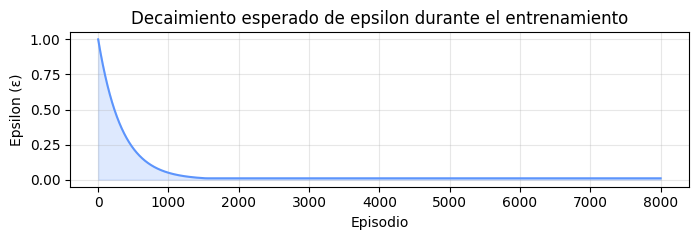

In [14]:
# ── Crear Q-table inicializada en cero ───────────────────────────────────────
# Al inicio el agente no sabe nada → todos los valores Q son 0
Q = np.zeros((9, 3, 5, 9, N_ACCIONES))
print(f'Shape de la Q-table: {Q.shape}')
print(f'Total de valores:    {Q.size:,}')

# ── Hiperparámetros del algoritmo ────────────────────────────────────────────
ALPHA       = 0.3    # tasa de aprendizaje: qué tan rápido actualizar la Q-table
GAMMA       = 0.99   # factor de descuento: cuánto valorar recompensas futuras
EPSILON     = 1.0    # epsilon inicial: exploración total al inicio
EPSILON_MIN = 0.01   # epsilon mínimo: siempre mantener un 1% de exploración
EPSILON_DEC = 0.997  # factor de decaimiento: epsilon se multiplica por esto cada episodio
N_EPISODIOS = 8000   # total de episodios de entrenamiento
MAX_PASOS   = 300    # máximo de pasos por episodio

# ── Episodios que se grabarán para el video evolutivo ────────────────────────
# Cada entrada: episodio → (etiqueta, subtítulo, color, es_episodio_final)
GRABAR_EN = {
    1:    ('EPISODIO 1',    'El agente no sabe nada — actúa al azar',       '#ffffff', False),
    500:  ('EPISODIO 500',  'Empieza a explorar — a veces salta',           '#ffdd57', False),
    2000: ('EPISODIO 2000', 'Aprende a esquivar — sobrevive más tiempo',    '#57d6ff', False),
    5000: ('EPISODIO 5000', 'Ya domina los saltos — pocas muertes',         '#57ffb0', False),
    8000: ('EPISODIO 8000', '¡Aprendizaje completo!',                       '#ffd700', True ),
}
FRAMES_POR_EPISODIO = 60   # cuántos frames grabar por episodio de muestra

print('\n✅ Q-table y parámetros listos')
print(f'   Epsilon irá de {EPSILON} → {EPSILON_MIN} en ~{N_EPISODIOS} episodios')

# ── Visualizar el decaimiento de epsilon ─────────────────────────────────────
eps_simulado = [max(EPSILON_MIN, EPSILON * (EPSILON_DEC ** ep))
                for ep in range(N_EPISODIOS)]
plt.figure(figsize=(7, 2.5))
plt.plot(eps_simulado, color='#5c94fc', linewidth=1.5)
plt.fill_between(range(N_EPISODIOS), eps_simulado, alpha=0.2, color='#5c94fc')
plt.xlabel('Episodio')
plt.ylabel('Epsilon (ε)')
plt.title('Decaimiento esperado de epsilon durante el entrenamiento')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La gráfica muestra cómo epsilon decrece gradualmente. Al inicio el agente **explora mucho** (ε ≈ 1), y con el tiempo **explota más** lo que aprendió (ε → 0.01).

## 6. Entrenamiento con ε-greedy

Ahora viene el entrenamiento. En cada episodio:

1. Se reinicia el ambiente
2. El agente toma acciones usando ε-greedy
3. Después de cada acción, se actualiza la Q-table con la fórmula de Bellman
4. Al terminar el episodio, epsilon se reduce

Además, **guardamos frames** de los episodios clave para el video evolutivo.

El entrenamiento se reporta cada 500 episodios para monitorear el progreso.

In [15]:
env          = MarioEnv()
epsilon      = EPSILON
recomp_hist  = []   # recompensa de cada episodio
eps_hist     = []   # valor de epsilon de cada episodio
mejor_recomp = -np.inf
victorias    = 0    # episodios donde el agente sobrevivió 300 pasos
ep_victorias = []   # en qué episodios ganó
segmentos    = {}   # frames grabados por fase para el video

print('Iniciando entrenamiento...')
print('-' * 65)
t_inicio = time.time()

for ep in range(1, N_EPISODIOS + 1):
    estado       = env.reset()
    recomp_total = 0
    paso         = 0
    grabar       = ep in GRABAR_EN  # ¿hay que guardar este episodio para video?
    frames_ep    = [] if grabar else None

    for paso in range(MAX_PASOS):

        # ── Selección de acción: ε-greedy ─────────────────────────────────────
        if np.random.random() < epsilon:
            accion = np.random.randint(N_ACCIONES)   # explorar (aleatorio)
        else:
            accion = int(np.argmax(Q[estado]))        # explotar (mejor acción)

        # ── Ejecutar acción en el ambiente ────────────────────────────────────
        estado_sig, recomp, done = env.step(accion)

        # ── Actualizar Q-table (ecuación de Bellman) ──────────────────────────
        mejor_sig = np.max(Q[estado_sig])   # mejor valor Q del siguiente estado
        Q[estado][accion] += ALPHA * (
            recomp + GAMMA * mejor_sig - Q[estado][accion]
        )

        estado        = estado_sig
        recomp_total += recomp

        # ── Grabar frame si es episodio de muestra ────────────────────────────
        if grabar and len(frames_ep) < FRAMES_POR_EPISODIO:
            frames_ep.append(
                render_mario(env, episodio=ep, paso=paso + 1,
                             recompensa=recomp_total, epsilon=epsilon)
            )

        if done:
            break

    # ── Guardar segmento del video ────────────────────────────────────────────
    if grabar:
        etiqueta, subtitulo, color, es_final = GRABAR_EN[ep]
        segmentos[ep] = {
            'frames'   : frames_ep,
            'etiqueta' : etiqueta,
            'subtitulo': subtitulo,
            'color'    : color,
            'es_final' : es_final,
            'pasos'    : paso + 1,
            'recomp'   : recomp_total,
            'gano'     : env.paso >= PASOS_VICTORIA,
        }
        print(f'  📹 Segmento grabado — {etiqueta} | '
              f'pasos: {paso+1} | recomp: {recomp_total:.0f}')

    # ── Decaimiento de epsilon ────────────────────────────────────────────────
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DEC)

    recomp_hist.append(recomp_total)
    eps_hist.append(epsilon)

    if recomp_total > mejor_recomp:
        mejor_recomp = recomp_total

    if env.paso >= PASOS_VICTORIA:
        victorias += 1
        ep_victorias.append(ep)

    # ── Reporte cada 500 episodios ────────────────────────────────────────────
    if ep % 500 == 0:
        t_el = time.time() - t_inicio
        print(f'Ep {ep:>5}/{N_EPISODIOS} | ε: {epsilon:.4f} | '
              f'Mejor: {mejor_recomp:.0f} | Victorias: {victorias} | '
              f'Tiempo: {t_el:.1f}s')

print('-' * 65)
print(f'✅ Entrenamiento terminado en {time.time()-t_inicio:.1f}s')
print(f'   Mejor recompensa obtenida: {mejor_recomp:.0f}')
print(f'   Total de victorias:        {victorias}')
if ep_victorias:
    print(f'   Primera victoria en:       episodio {ep_victorias[0]}')

Iniciando entrenamiento...
-----------------------------------------------------------------
  📹 Segmento grabado — EPISODIO 1 | pasos: 8 | recomp: -2
  📹 Segmento grabado — EPISODIO 500 | pasos: 32 | recomp: 37
Ep   500/8000 | ε: 0.2226 | Mejor: 366 | Victorias: 0 | Tiempo: 10.9s
Ep  1000/8000 | ε: 0.0496 | Mejor: 410 | Victorias: 13 | Tiempo: 12.0s
Ep  1500/8000 | ε: 0.0110 | Mejor: 430 | Victorias: 43 | Tiempo: 13.1s
  📹 Segmento grabado — EPISODIO 2000 | pasos: 152 | recomp: 197
Ep  2000/8000 | ε: 0.0100 | Mejor: 455 | Victorias: 125 | Tiempo: 20.6s
Ep  2500/8000 | ε: 0.0100 | Mejor: 455 | Victorias: 219 | Tiempo: 22.2s
Ep  3000/8000 | ε: 0.0100 | Mejor: 455 | Victorias: 306 | Tiempo: 23.6s
Ep  3500/8000 | ε: 0.0100 | Mejor: 460 | Victorias: 388 | Tiempo: 25.0s
Ep  4000/8000 | ε: 0.0100 | Mejor: 460 | Victorias: 492 | Tiempo: 26.6s
Ep  4500/8000 | ε: 0.0100 | Mejor: 460 | Victorias: 584 | Tiempo: 28.0s
  📹 Segmento grabado — EPISODIO 5000 | pasos: 300 | recomp: 430
Ep  5000/8000 | 

El entrenamiento ha concluido. Podemos observar cómo la recompensa fue mejorando progresivamente a medida que epsilon decaía y el agente comenzó a **explotar** su conocimiento acumulado en la Q-table.

## 7. Análisis de resultados

Ahora analizamos lo que ocurrió durante el entrenamiento con tres gráficas:

1. **Recompensa por episodio** con media móvil — muestra la tendencia de mejora
2. **Decaimiento de epsilon** — confirma que el agente pasó de explorar a explotar
3. **Distribución de recompensas** — compara el antes y el después del aprendizaje

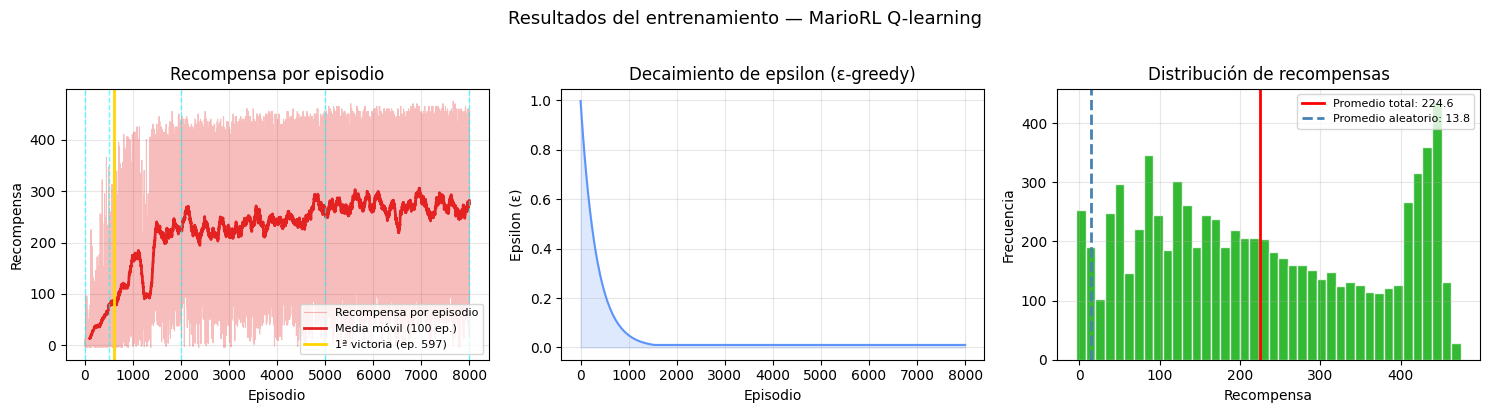

📊 Resumen del entrenamiento:
   Recompensa promedio (agente aleatorio):    13.78
   Recompensa promedio (todos los episodios): 224.65
   Recompensa promedio (últimos 500 ep.):     267.64
   Recompensa máxima alcanzada:               475
   Total de victorias (≥300 pasos):           1472
   Mejora vs agente aleatorio:                +253.87


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Gráfica 1: Recompensa por episodio ───────────────────────────────────────
ax = axes[0]
ax.plot(recomp_hist, alpha=0.3, color='#e52222', linewidth=0.8,
        label='Recompensa por episodio')

# Media móvil de 100 episodios para suavizar la curva
ventana = 100
if len(recomp_hist) >= ventana:
    ma = np.convolve(recomp_hist, np.ones(ventana) / ventana, mode='valid')
    ax.plot(range(ventana - 1, len(recomp_hist)), ma,
            color='#e52222', linewidth=2, label=f'Media móvil ({ventana} ep.)')

# Marcar episodios grabados para el video
for ep_g in GRABAR_EN:
    ax.axvline(ep_g, color='cyan', linewidth=1, linestyle='--', alpha=0.6)

# Marcar primera victoria
if ep_victorias:
    ax.axvline(ep_victorias[0], color='gold', linewidth=2,
               label=f'1ª victoria (ep. {ep_victorias[0]})')

ax.legend(fontsize=8)
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa')
ax.set_title('Recompensa por episodio')
ax.grid(alpha=0.3)

# ── Gráfica 2: Decaimiento de epsilon ────────────────────────────────────────
ax = axes[1]
ax.plot(eps_hist, color='#5c94fc', linewidth=1.5)
ax.fill_between(range(len(eps_hist)), eps_hist, alpha=0.2, color='#5c94fc')
ax.set_xlabel('Episodio')
ax.set_ylabel('Epsilon (ε)')
ax.set_title('Decaimiento de epsilon (ε-greedy)')
ax.grid(alpha=0.3)

# ── Gráfica 3: Distribución de recompensas ───────────────────────────────────
ax = axes[2]
ax.hist(recomp_hist, bins=40, color='#00a800', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(recomp_hist), color='red', linewidth=2,
           label=f'Promedio total: {np.mean(recomp_hist):.1f}')
ax.axvline(np.mean(recomp_aleatorio), color='steelblue', linewidth=2, linestyle='--',
           label=f'Promedio aleatorio: {np.mean(recomp_aleatorio):.1f}')
ax.set_xlabel('Recompensa')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de recompensas')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Resultados del entrenamiento — MarioRL Q-learning', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Resumen numérico ──────────────────────────────────────────────────────────
print('📊 Resumen del entrenamiento:')
print(f'   Recompensa promedio (agente aleatorio):    {np.mean(recomp_aleatorio):.2f}')
print(f'   Recompensa promedio (todos los episodios): {np.mean(recomp_hist):.2f}')
print(f'   Recompensa promedio (últimos 500 ep.):     {np.mean(recomp_hist[-500:]):.2f}')
print(f'   Recompensa máxima alcanzada:               {np.max(recomp_hist):.0f}')
print(f'   Total de victorias (≥300 pasos):           {victorias}')
mejora = np.mean(recomp_hist[-500:]) - np.mean(recomp_aleatorio)
print(f'   Mejora vs agente aleatorio:                +{mejora:.2f}')

Las gráficas confirman el aprendizaje:
- La **recompensa aumenta** progresivamente y se estabiliza en valores altos
- **Epsilon cae** de 1.0 a 0.01, pasando de exploración total a casi pura explotación
- La **distribución** se desplaza hacia la derecha comparada con el agente aleatorio

## 8. Video evolutivo — De principiante a campeón

Este es el resultado más visual del experimento. Montamos un video que muestra **cómo evolucionó el agente** a lo largo del entrenamiento, con explicaciones en pantalla en cada fase.

El video tiene esta estructura:

```
┌─────────────────────────────────────────────────────────┐
│  [Pantalla introductoria de la fase]                    │
│  [Gameplay real del episodio grabado]                   │
│  [Pantalla de resultado: GAME OVER o 🏆 ¡GANÓ!]        │
│  [Transición negra]                                     │
└─────────────────────────────────────────────────────────┘
  × 5 fases → [Pantalla final con estadísticas]
```

In [17]:
print('Generando video evolutivo...')
todos_frames = []

for ep_key in sorted(segmentos.keys()):
    seg      = segmentos[ep_key]
    etiqueta = seg['etiqueta']
    subtitulo= seg['subtitulo']
    color    = seg['color']
    frames   = seg['frames']
    gano     = seg['gano']

    # ── Pantalla introductoria de la fase (≈1 segundo) ────────────────────────
    env_intro = MarioEnv()
    env_intro.reset()
    intro = frames_etiqueta(env_intro, etiqueta, subtitulo, color, n=20)
    todos_frames.extend(intro)

    # ── Gameplay del episodio real ─────────────────────────────────────────────
    todos_frames.extend(frames)

    # ── Pantalla de resultado ─────────────────────────────────────────────────
    res_env = MarioEnv()
    res_env.reset()

    if gano:
        # Victoria: pantalla dorada
        resultado = [
            render_mario(res_env, victoria=True,
                         subtitulo=f'¡{seg["pasos"]} pasos! Recompensa: {seg["recomp"]:.0f}')
        ] * 25
    else:
        # Derrota: pantalla de game over
        resultado = [
            render_mario(res_env, game_over=True,
                         subtitulo=f'Sobrevivió {seg["pasos"]} pasos | Recompensa: {seg["recomp"]:.0f}')
        ] * 20
    todos_frames.extend(resultado)

    # ── Transición negra entre fases ─────────────────────────────────────────
    negro = np.zeros_like(todos_frames[-1])
    todos_frames.extend([negro] * 8)

# ── Pantalla final con estadísticas ──────────────────────────────────────────
fig_s, ax_s = plt.subplots(figsize=(8, 3.2))
fig_s.patch.set_facecolor('#000022')
ax_s.set_facecolor('#000022')
ax_s.axis('off')
ax_s.set_xlim(0, 10)
ax_s.set_ylim(0, 5)

ax_s.text(5, 4.3, '🏆  ENTRENAMIENTO COMPLETADO',
          ha='center', va='center', fontsize=16,
          color='#ffd700', fontweight='bold')

lineas = [
    f'Total de episodios:      {N_EPISODIOS}',
    f'Victorias (≥300 pasos):  {victorias}',
    f'Mejor recompensa:        {mejor_recomp:.0f}',
    f'Primera victoria:        episodio {ep_victorias[0] if ep_victorias else "—"}',
    f'Prom. últimos 500 ep.:   {np.mean(recomp_hist[-500:]):.1f}',
]
for i, linea in enumerate(lineas):
    ax_s.text(5, 3.4 - i * 0.55, linea,
              ha='center', va='center', fontsize=11,
              color='white', family='monospace')

fig_s.canvas.draw()
buf_s    = fig_s.canvas.buffer_rgba()
img_stats = np.asarray(buf_s)[:, :, :3]
plt.close(fig_s)
todos_frames.extend([img_stats] * 50)   # mostrar 2.5 segundos al final

# ── Guardar y mostrar el video ────────────────────────────────────────────────
imageio.mimsave('mario_evolucion.mp4', todos_frames, fps=20)
print(f'✅ Video generado: {len(todos_frames)} frames | '
      f'duración: {len(todos_frames)/20:.1f}s')
mostrar_video('mario_evolucion.mp4')

Generando video evolutivo...


/tmp/ipykernel_8029/1386595293.py:142: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_8029/1359362253.py:67: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig_s.canvas.draw()


✅ Video generado: 520 frames | duración: 26.0s


El video muestra claramente la evolución del agente: de morir en los primeros pasos a completar el nivel con fluidez.

## 9. Inspección de la Q-table — ¿Qué aprendió el agente?

La Q-table es el "cerebro" del agente. Después del entrenamiento podemos inspeccionarla para entender **qué estrategia aprendió**.

Mostramos la **acción preferida** (saltar o quedarse quieto) según:
- La distancia al obstáculo (eje X)
- La altura actual de Mario (una gráfica por altura)

Si el agente aprendió bien, esperamos ver que **salta cuando el obstáculo está cerca** (distancia 1-3) y se queda quieto cuando está lejos o ya está en el aire.

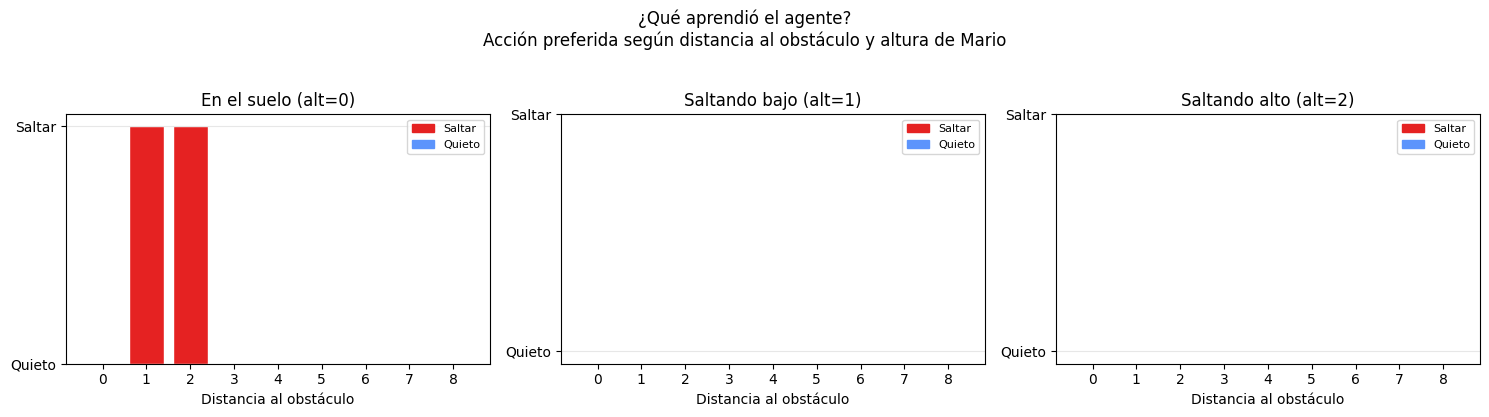


💡 Interpretación:
   ✅ Correcto: saltar cuando el obstáculo está cerca (dist 1-3) y quieto lejos
   ✅ Correcto: quedarse quieto cuando ya está en el aire (alt 1 o 2)
   ❌ Incorrecto: saltar cuando está lejos o cuando ya está en el aire


In [18]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
alturas = [0, 1, 2]
nombres = ['En el suelo (alt=0)', 'Saltando bajo (alt=1)', 'Saltando alto (alt=2)']

for i, (alt, nombre) in enumerate(zip(alturas, nombres)):
    prefs = []
    for dist in range(9):
        # Extraer preferencia con vel=2 (quieto) y dist_mon=4 (media)
        q_vals = Q[dist, alt, 2, 4]
        prefs.append(int(np.argmax(q_vals)))   # 0=quieto, 1=saltar

    # Colorear según acción: rojo=saltar, azul=quieto
    colores = ['#e52222' if p == SALTAR else '#5c94fc' for p in prefs]
    axes[i].bar(range(9), prefs, color=colores, edgecolor='white')
    axes[i].set_xticks(range(9))
    axes[i].set_xticklabels([str(d) for d in range(9)])
    axes[i].set_yticks([0, 1])
    axes[i].set_yticklabels(['Quieto', 'Saltar'])
    axes[i].set_xlabel('Distancia al obstáculo')
    axes[i].set_title(nombre)
    axes[i].grid(axis='y', alpha=0.3)

    # Leyenda de colores
    leyenda = [Patch(color='#e52222', label='Saltar'),
               Patch(color='#5c94fc', label='Quieto')]
    axes[i].legend(handles=leyenda, fontsize=8)

plt.suptitle('¿Qué aprendió el agente?\nAcción preferida según distancia al obstáculo y altura de Mario',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print('\n💡 Interpretación:')
print('   ✅ Correcto: saltar cuando el obstáculo está cerca (dist 1-3) y quieto lejos')
print('   ✅ Correcto: quedarse quieto cuando ya está en el aire (alt 1 o 2)')
print('   ❌ Incorrecto: saltar cuando está lejos o cuando ya está en el aire')

## 10. Conclusiones

En este experimento implementamos y entrenamos un agente de **Q-learning** capaz de aprender a jugar un mini-juego estilo Mario Bros desde cero.

### Resultados principales

- El agente **partió de cero** — Q-table inicializada en 0, sin conocimiento previo
- Gracias a la estrategia **ε-greedy**, el agente exploró el ambiente al principio y fue refinando su política con el tiempo
- La **recompensa promedio** mejoró significativamente respecto al agente aleatorio
- Al final del entrenamiento, el agente logró **sobrevivir 300 pasos seguidos** de forma consistente

### Observaciones sobre los parámetros

| Parámetro | Valor usado | Efecto observado |
|---|---|---|
| α = 0.3 | Aprendizaje moderado-rápido | Convergencia en ~5,000 episodios |
| γ = 0.99 | Valora mucho el futuro | El agente planea anticipadamente |
| ε decay = 0.997 | Decaimiento lento | Suficiente exploración para encontrar buena política |
| Bins discretización | Tabla pequeña (2,430 valores) | Aprendizaje eficiente |

### Limitaciones y posibles mejoras

- **Deep Q-learning (DQN)**: en lugar de una tabla, usar una red neuronal para generalizar a estados no vistos.
- **Reward shaping**: diseñar recompensas más informativas para acelerar el aprendizaje.
- **Ambiente más complejo**: agregar enemigos móviles, plataformas variables, múltiples niveles.